Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


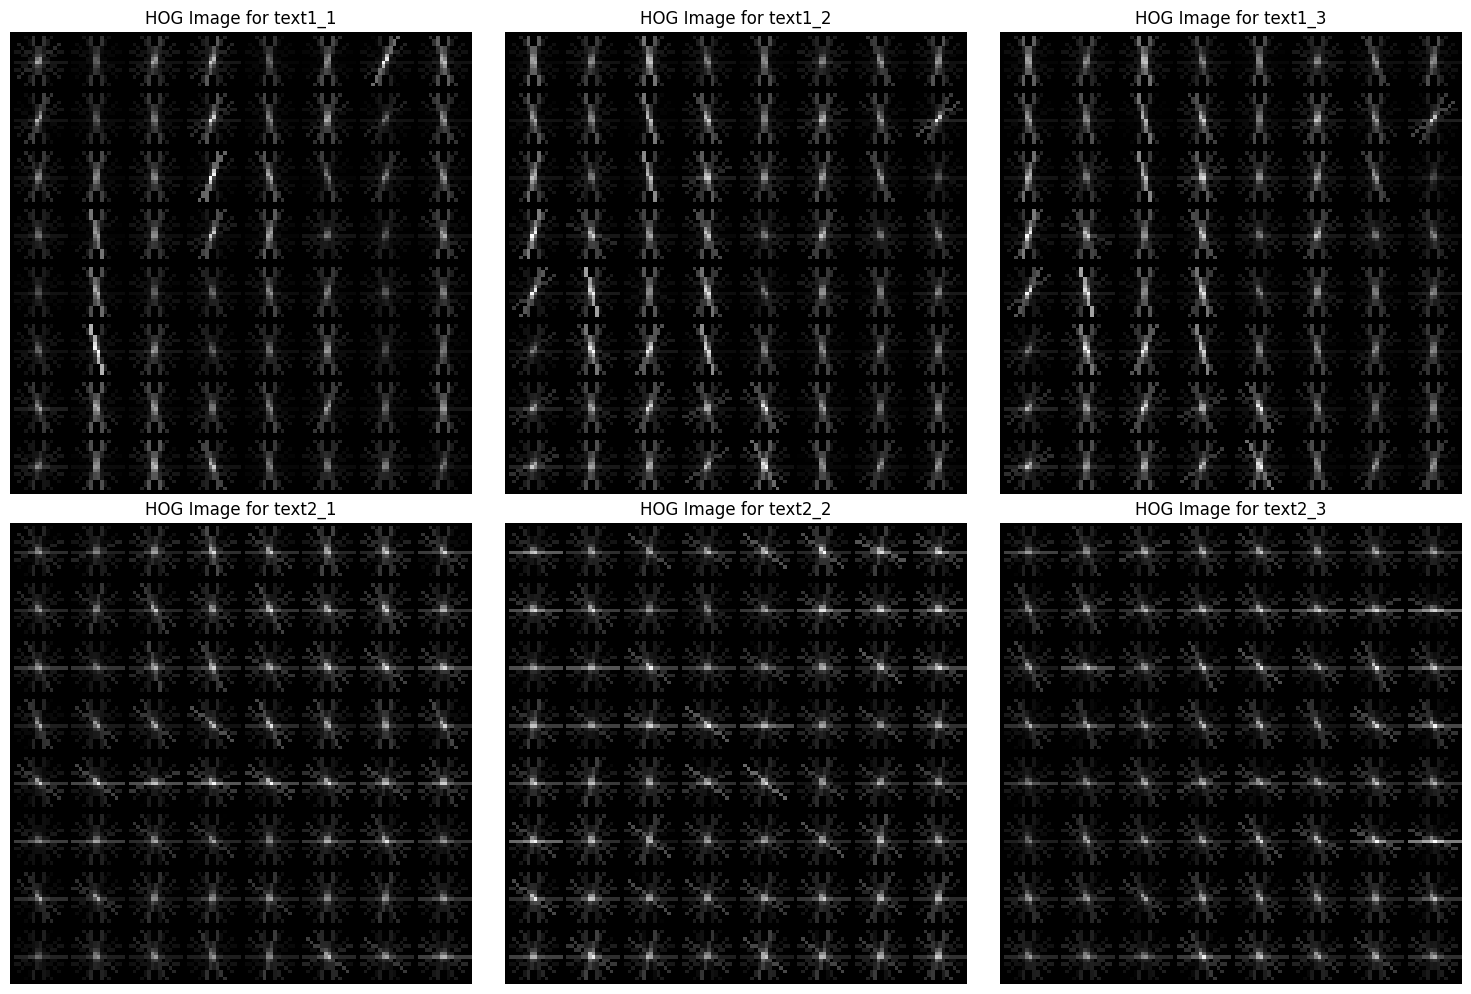


--- Euclidean Distances ---
         text1_1  text1_2  text2_1  text2_2
text1_1   0.0000   2.7500   3.9855   4.2725
text1_2   2.7500   0.0000   3.8206   4.1047
text2_1   3.9855   3.8206   0.0000   2.5748
text2_2   4.2725   4.1047   2.5748   0.0000

--- Cosine Similarities ---
         text1_1  text1_2  text2_1  text2_2
text1_1   1.0000   0.9228   0.8379   0.8137
text1_2   0.9228   1.0000   0.8511   0.8281
text2_1   0.8379   0.8511   1.0000   0.9324
text2_2   0.8137   0.8281   0.9324   1.0000

--- Chi-Squared Distances ---
         text1_1  text1_2  text2_1  text2_2
text1_1   0.0000  14.0209  26.8573  30.5086
text1_2  14.0209   0.0000  24.9324  28.3758
text2_1  26.8573  24.9324   0.0000  11.8501
text2_2  30.5086  28.3758  11.8501   0.0000


Classificação para hog_text1_3: Classe 1
  Distância para Classe 1 (média): 4.0061
  Distância para Classe 2 (média): 24.0573
Classificação para hog_text2_3: Classe 2
  Distância para Classe 1 (média): 29.1748
  Distância para Classe 2 (média): 9.33

In [6]:
from google.colab import drive
drive.mount('/content/drive')

import cv2
from google.colab.patches import cv2_imshow
import matplotlib.pyplot as plt
import numpy as np

import numpy as np
import pandas as pd
from scipy.spatial.distance import cosine

from skimage.feature import hog

#1. Carrega as imagens
text1_1 = cv2.imread('/content/drive/MyDrive/Pesquisa/Visão Computacional/imagens/Quest3/text1_1.png')
text1_2 = cv2.imread('/content/drive/MyDrive/Pesquisa/Visão Computacional/imagens/Quest3/text1_2.png')
text1_3 = cv2.imread('/content/drive/MyDrive/Pesquisa/Visão Computacional/imagens/Quest3/text1_3.png')

text2_1 = cv2.imread('/content/drive/MyDrive/Pesquisa/Visão Computacional/imagens/Quest3/text2_1.png')
text2_2 = cv2.imread('/content/drive/MyDrive/Pesquisa/Visão Computacional/imagens/Quest3/text2_2.png')
text2_3 = cv2.imread('/content/drive/MyDrive/Pesquisa/Visão Computacional/imagens/Quest3/text2_3.png')


#função que estrai o descritor hog das imagens
def extrair_hog(img):
    # Carregar em escala de cinza (HOG trabalha com gradientes de intensidade)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    # Redimensionar para garantir que o vetor de características tenha sempre o mesmo tamanho
    # 128x128 é um bom tamanho para capturar a textura sem pesar o processamento
    img_resized = cv2.resize(img, (128, 128))

    # Extração do HOG
    # orientations=9: divide os gradientes em 9 direções (0 a 180 graus)
    # pixels_per_cell=(16, 16): agrupa pixels em células
    # cells_per_block=(2, 2): normalização em blocos para lidar com iluminação
    features, hog_image = hog(img_resized,
                   orientations=9,
                   pixels_per_cell=(16, 16),
                   cells_per_block=(2, 2),
                   block_norm='L2-Hys',
                   visualize=True)

    return features, hog_image

# Extrai o descritor hog de cada imagem
hog_text1_1, hog_image_text1_1 = extrair_hog(text1_1)
hog_text1_2, hog_image_text1_2 = extrair_hog(text1_2)
hog_text1_3, hog_image_text1_3 = extrair_hog(text1_3)
hog_text2_1, hog_image_text2_1 = extrair_hog(text2_1)
hog_text2_2, hog_image_text2_2 = extrair_hog(text2_2)
hog_text2_3, hog_image_text2_3 = extrair_hog(text2_3)

#imprime a imagem dos descritores hog:

# Create a figure and a 2x3 grid of subplots
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Flatten the axes array for easy iteration
axes = axes.flatten()

# List of HOG images and their corresponding titles
hog_images = [
    (hog_image_text1_1, "text1_1"),
    (hog_image_text1_2, "text1_2"),
    (hog_image_text1_3, "text1_3"),
    (hog_image_text2_1, "text2_1"),
    (hog_image_text2_2, "text2_2"),
    (hog_image_text2_3, "text2_3")
]

# Display each HOG image in its subplot
for i, (image, title) in enumerate(hog_images):
    axes[i].imshow(image, cmap='gray')
    axes[i].set_title(f"HOG Image for {title}")
    axes[i].axis('off') # Turn off axis labels and ticks

# Adjust layout and display the plot
plt.tight_layout()
plt.show()
print

hog_features = [hog_text1_1, hog_text1_2, hog_text2_1, hog_text2_2]
hog_labels = ["text1_1", "text1_2", "text2_1", "text2_2"]

#2. Testar algumas métricas para decidir qual vai utilizar:

# Initialize 4x4 matrices for each metric
euclidean_distances = np.zeros((len(hog_features), len(hog_features)))
cosine_similarities = np.zeros((len(hog_features), len(hog_features)))
chi_squared_distances = np.zeros((len(hog_features), len(hog_features)))

def chi_squared_distance(hist1, hist2):
    # Adiciona um pequeno epsilon para evitar divisão por zero
    epsilon = 1e-10
    return 0.5 * np.sum(((hist1 - hist2)**2) / (hist1 + hist2 + epsilon))

# Iterate through all pairs to calculate metrics
for i in range(len(hog_features)):
    for j in range(len(hog_features)):
        hog_i = hog_features[i]
        hog_j = hog_features[j]

        # Euclidean Distance
        euclidean_distances[i, j] = np.linalg.norm(hog_i - hog_j)

        # Cosine Similarity
        # scipy.spatial.distance.cosine returns the cosine distance, so 1 - distance gives similarity
        cosine_similarities[i, j] = 1 - cosine(hog_i, hog_j)

        # Chi-Squared Distance
        chi_squared_distances[i, j] = chi_squared_distance(hog_i, hog_j)



# Function to display a matrix with labels
def display_matrix(matrix, title, labels):
    df = pd.DataFrame(matrix, index=labels, columns=labels)
    print(f"\n--- {title} ---")
    print(df.round(4))

# Display Euclidean Distances
display_matrix(euclidean_distances, "Euclidean Distances", hog_labels)

# Display Cosine Similarities
display_matrix(cosine_similarities, "Cosine Similarities", hog_labels)

# Display Chi-Squared Distances
display_matrix(chi_squared_distances, "Chi-Squared Distances", hog_labels)
print("\n")

#3. Classificação as iamgens hog_text1_3 e  hog_text2_3

# Calcular o HOG médio para a Classe 1 (treino)
avg_hog_class1 = (hog_text1_1 + hog_text1_2) / 2

# Calcular o HOG médio para a Classe 2 (treino)
avg_hog_class2 = (hog_text2_1 + hog_text2_2) / 2


# Função para classificar uma imagem de teste usando Chi-Squared Distance
def classify_image_by_chi_squared_distance(test_hog, avg_hog_class1, avg_hog_class2):
    # Adiciona um pequeno epsilon para evitar divisão por zero
    epsilon = 1e-10

    # Calcula a distância Chi-Squared para a Classe 1
    dist_to_class1 = chi_squared_distance (test_hog, avg_hog_class1)

    # Calcula a distância Chi-Squared para a Classe 2
    dist_to_class2 = chi_squared_distance (test_hog, avg_hog_class2)

    if dist_to_class1 < dist_to_class2:
        return "Classe 1", dist_to_class1, dist_to_class2
    else:
        return "Classe 2", dist_to_class1, dist_to_class2

# 3. Classificar hog_text1_3
pred_class1_3, dist1_1_3, dist2_1_3 = classify_image_by_chi_squared_distance(hog_text1_3, avg_hog_class1, avg_hog_class2)
print(f"Classificação para hog_text1_3: {pred_class1_3}")
print(f"  Distância para Classe 1 (média): {dist1_1_3:.4f}")
print(f"  Distância para Classe 2 (média): {dist2_1_3:.4f}")

# 4. Classificar hog_text2_3
pred_class2_3, dist1_2_3, dist2_2_3 = classify_image_by_chi_squared_distance(hog_text2_3, avg_hog_class1, avg_hog_class2)
print(f"Classificação para hog_text2_3: {pred_class2_3}")
print(f"  Distância para Classe 1 (média): {dist1_2_3:.4f}")
print(f"  Distância para Classe 2 (média): {dist2_2_3:.4f}")